In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

we will use the life satisfaction data for understanding the different basic machine learning model

In [2]:
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root+"lifesat/lifesat.csv")


In [3]:
lifesat.dtypes

Country                  object
GDP per capita (USD)    float64
Life satisfaction       float64
dtype: object

In [4]:
lifesat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     object 
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), object(1)
memory usage: 776.0+ bytes


In [5]:
lifesat.head(10)

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6
5,Portugal,32181.154537,5.4
6,Poland,32238.157259,6.1
7,Estonia,35638.421351,5.7
8,Spain,36215.447591,6.3
9,Slovenia,36547.738956,5.9


In [6]:
lifesat.shape

(27, 3)

In [7]:
lifesat.describe()

,GDP per capita (USD),Life satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


In [8]:
lifesat.isnull().sum()

Country                 0
GDP per capita (USD)    0
Life satisfaction       0
dtype: int64

to find the correlation of GDP and Life satisfaction rate

In [9]:
lifesat["GDP per capita (USD)"].corr(lifesat["Life satisfaction"])

0.8527960443900199

In [10]:
lifesat["Life satisfaction"].corr(lifesat["GDP per capita (USD)"])

0.8527960443900198

In [11]:
lifesat.corr()

ValueError: could not convert string to float: 'Russia'

# **lets visulize the dataset through plots**
## note:  features with only numerical type willllll be shown 

<Axes: >

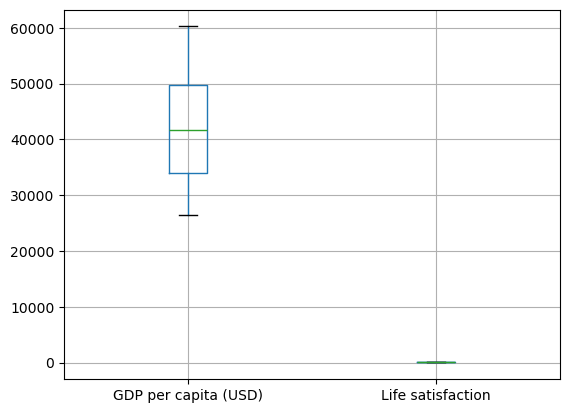

In [11]:
lifesat.boxplot()

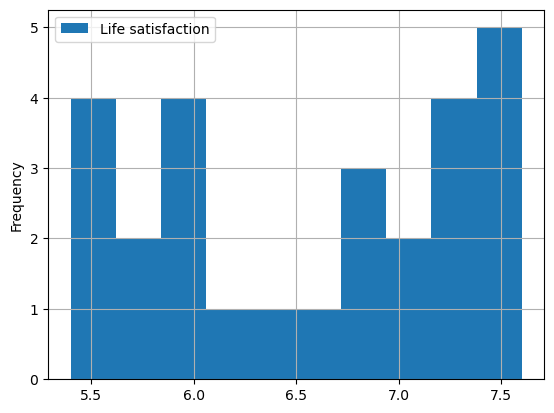

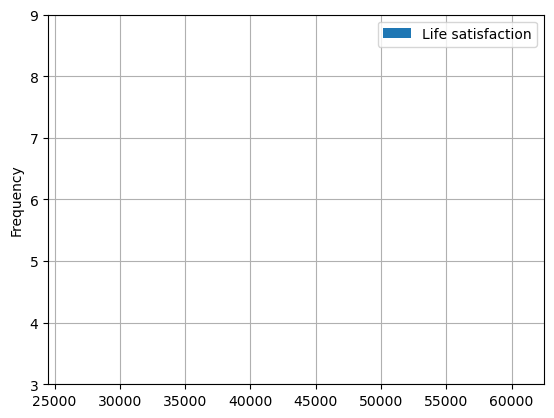

In [14]:
lifesat.plot(kind="hist",grid=True , x="GDP per capita (USD)" , y="Life satisfaction")
plt.axis([24500,62500,3,9])
plt.show()

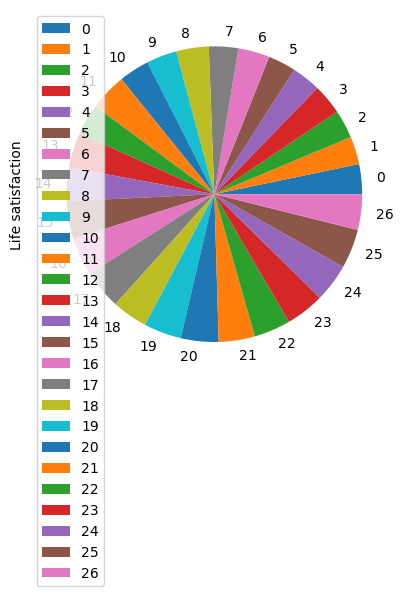

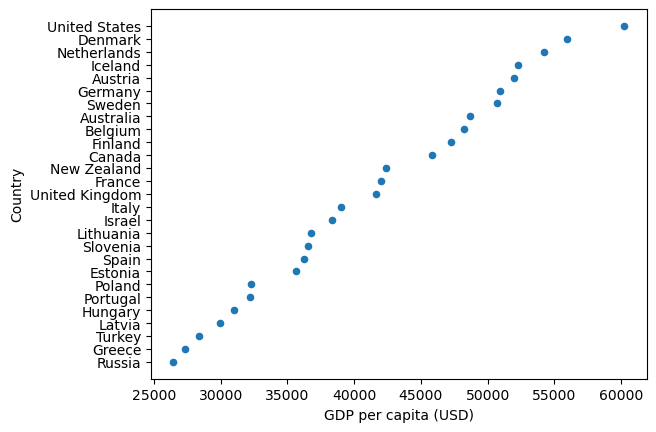

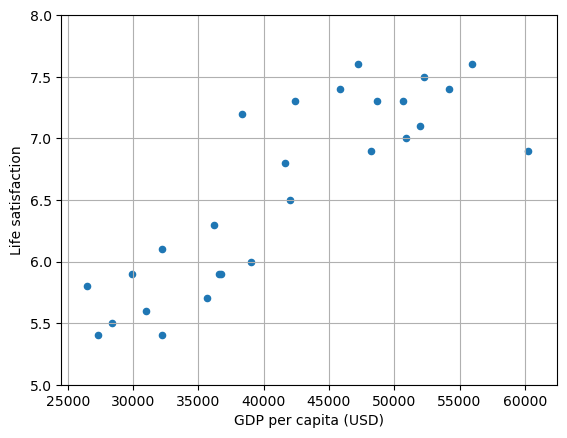

In [17]:
lifesat.plot(kind='scatter',grid=True , x="GDP per capita (USD)" , y="Life satisfaction")
plt.axis([24500,62500,5,8])
plt.show()

# **now let's train the model using basic machine learning regression models**

## -Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

In [19]:
X = lifesat["GDP per capita (USD)"].values
y = lifesat["Life satisfaction"].values


In [24]:
X.resize(27,1)
X

array([[26456.38793813],
       [27287.08340093],
       [28384.98778463],
       [29932.49391006],
       [31007.76840654],
       [32181.15453723],
       [32238.15725928],
       [35638.42135118],
       [36215.44759073],
       [36547.73895598],
       [36732.03474403],
       [38341.30757041],
       [38992.14838075],
       [41627.12926943],
       [42025.61737306],
       [42404.39373816],
       [45856.62562648],
       [47260.80045844],
       [48210.03311134],
       [48697.83702825],
       [50683.32350972],
       [50922.35802345],
       [51935.60386182],
       [52279.72885136],
       [54209.56383573],
       [55938.2128086 ],
       [60235.7284917 ]])

In [25]:
y.resize(27,1)
y

array([[5.8],
       [5.4],
       [5.5],
       [5.9],
       [5.6],
       [5.4],
       [6.1],
       [5.7],
       [6.3],
       [5.9],
       [5.9],
       [7.2],
       [6. ],
       [6.8],
       [6.5],
       [7.3],
       [7.4],
       [7.6],
       [6.9],
       [7.3],
       [7.3],
       [7. ],
       [7.1],
       [7.5],
       [7.4],
       [7.6],
       [6.9]])

In [26]:
linear_model.fit(X=X,y=y)

LinearRegression()

In [27]:
linear_model.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [28]:
linear_model.n_features_in_

1

In [29]:
linear_model.score(X,y)

0.7272610933272652

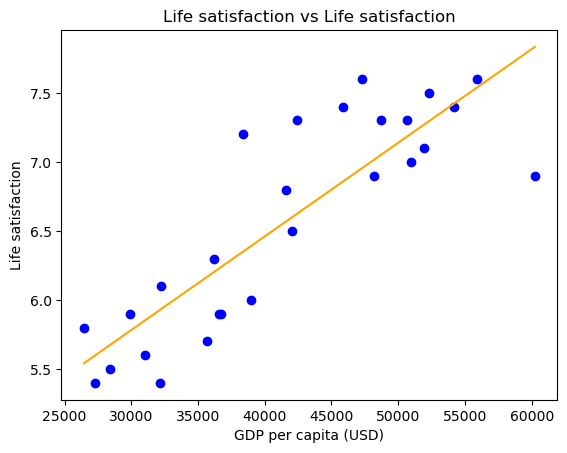

In [30]:
# Prediction 
Y_pred = linear_model.predict( X )
# Visualization 
plt.scatter( X, y, color = 'blue' )
plt.plot( X, Y_pred, color = 'orange' )
plt.title( 'Life satisfaction vs Life satisfaction' )
plt.xlabel( 'GDP per capita (USD)' )
plt.ylabel( 'Life satisfaction' )
plt.show()

## -polynomial regression

### vary the **degree** parameter to see how the graph changes

In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X=X)

In [16]:
poly.fit(X=X_poly,y=y)
poly_model = LinearRegression()
poly_model.fit(X=X_poly,y=y)

LinearRegression()

In [17]:
poly_model.n_features_in_

4

In [18]:
poly_model.score(X_poly,y)

0.8234326065331602

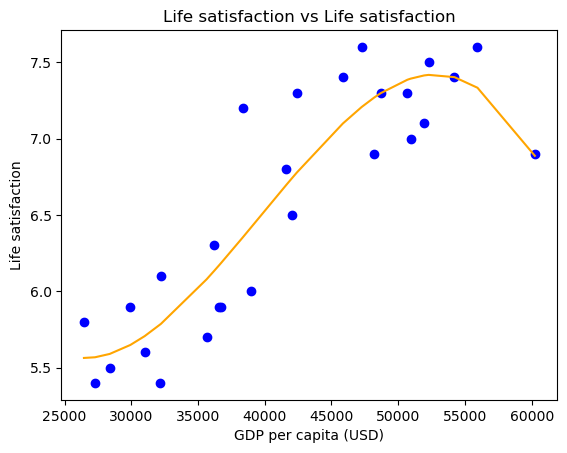

In [19]:
# Prediction 
Y_pred = poly_model.predict(X_poly)
# Visualization 
plt.scatter( X, y, color = 'blue' )
plt.plot( X, Y_pred, color = 'orange' )
plt.title( 'Life satisfaction vs Life satisfaction' )
plt.xlabel( 'GDP per capita (USD)' )
plt.ylabel( 'Life satisfaction' )
plt.show()

## -Support vector Regression **(SVR)**
    -change the parameters 
        - kernel = {"linear","poly","rbf"}
        - degree = int values

/home/chethan/Documents/MONISH/machine_learning/chapter_1/.conda/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


train accuracy -3730.5655019129163


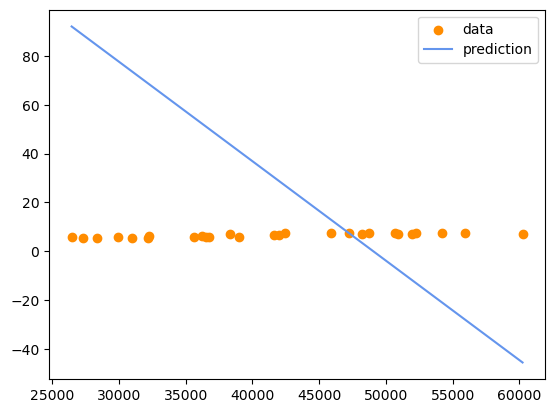

In [32]:
from sklearn.svm import SVR

svr_linear = SVR(kernel="linear",degree=5)
SVR(kernel="")

svr_linear.fit(X=X , y=y)

print("train accuracy" , svr_linear.score(X ,y))

# make predictions on the data 
y_pred = svr_linear.predict(X) 
  
# plot the predicted values against the true values 
plt.scatter(X, y, color='darkorange', 
            label='data') 
plt.plot(X, y_pred, color='cornflowerblue', 
         label='prediction') 
plt.legend() 
plt.show() 

/home/chethan/Documents/MONISH/machine_learning/chapter_1/.conda/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


train accuracy 0.3021267060642596


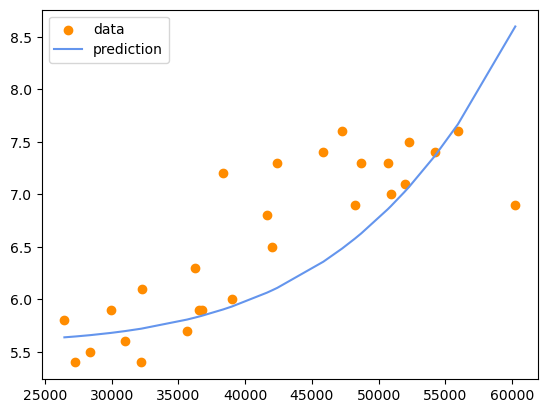

In [33]:
svr_linear = SVR(kernel="poly",degree=5)
SVR(kernel="")

svr_linear.fit(X=X , y=y)

print("train accuracy" , svr_linear.score(X ,y))

# make predictions on the data 
y_pred = svr_linear.predict(X) 
  
# plot the predicted values against the true values 
plt.scatter(X, y, color='darkorange', 
            label='data') 
plt.plot(X, y_pred, color='cornflowerblue', 
         label='prediction') 
plt.legend() 
plt.show() 

train accuracy 0.8260790068287102


/home/chethan/Documents/MONISH/machine_learning/chapter_1/.conda/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


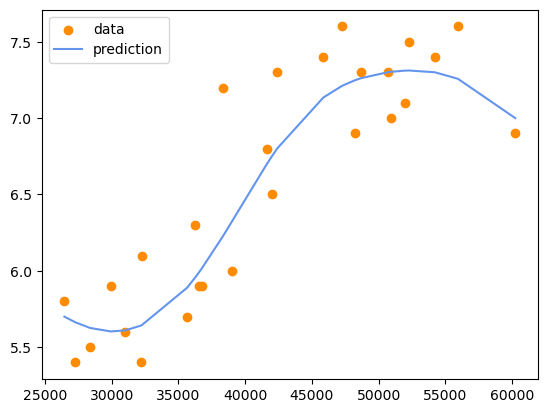

In [34]:
svr_linear = SVR(kernel="rbf",degree=5)
SVR(kernel="")

svr_linear.fit(X=X , y=y)

print("train accuracy" , svr_linear.score(X ,y))

# make predictions on the data 
y_pred = svr_linear.predict(X) 
  
# plot the predicted values against the true values 
plt.scatter(X, y, color='darkorange', 
            label='data') 
plt.plot(X, y_pred, color='cornflowerblue', 
         label='prediction') 
plt.legend() 
plt.show() 

/home/chethan/Documents/MONISH/machine_learning/chapter_1/.conda/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


train accuracy -0.05954745925609384


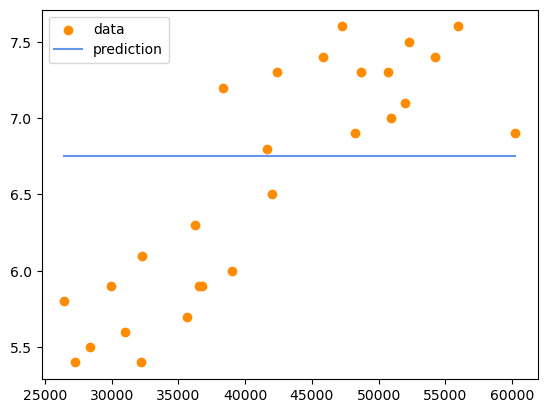

In [35]:
svr_linear = SVR(kernel="sigmoid",degree=5)
SVR(kernel="")

svr_linear.fit(X=X , y=y)

print("train accuracy" , svr_linear.score(X ,y))

# make predictions on the data 
y_pred = svr_linear.predict(X) 
  
# plot the predicted values against the true values 
plt.scatter(X, y, color='darkorange', 
            label='data') 
plt.plot(X, y_pred, color='cornflowerblue', 
         label='prediction') 
plt.legend() 
plt.show() 

## -KNeighborsRegressor

In [45]:
from sklearn.neighbors import KNeighborsRegressor
KNR_model = KNeighborsRegressor(n_neighbors=2)

In [46]:
KNR_model.fit(X=X,y=y)
KNR_model.score(X ,y)

0.8658136482939633

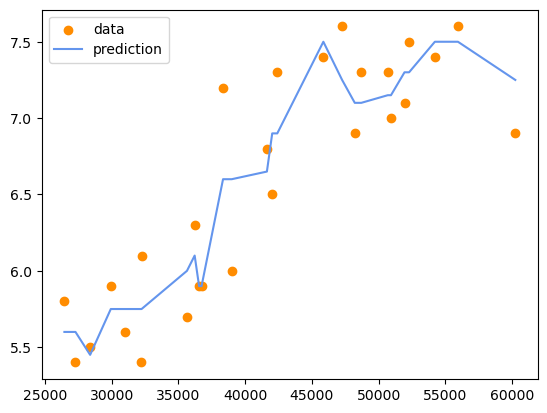

In [47]:
# make predictions on the data 
y_pred = KNR_model.predict(X) 
  
# plot the predicted values against the true values 
plt.scatter(X, y, color='darkorange', 
            label='data') 
plt.plot(X, y_pred, color='cornflowerblue', 
         label='prediction') 
plt.legend() 
plt.show() 